<a href="https://colab.research.google.com/github/Hindabuzarour/Hindabuzarour/blob/main/Project_4_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_sampler_pipeline
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

In [80]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)
  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)
  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
  axes[0].set_title("Raw Counts")
  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")
  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [81]:
def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,
                    'test': results_test}
    return results_dict

In [82]:
fpath='/content/drive/MyDrive/Colab Notebooks/adult.csv'
df=pd.read_csv(fpath)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


### Data Cleaning

In [83]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


99999 consider unknown values

In [84]:
count = len(df[df['capital-gain'] == 99999])
print(count)

244


In [85]:
filtered_df = df[df['capital-gain'] == 99999]
filtered_df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
83,44,Self-emp-inc,223881,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,50,?,>50K
346,39,Private,198654,HS-grad,9,Divorced,Exec-managerial,Unmarried,Black,Female,99999,0,40,United-States,>50K
357,50,Self-emp-not-inc,165001,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,80,United-States,>50K
418,54,Self-emp-inc,159219,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,99999,0,40,United-States,>50K
692,41,Private,191547,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48109,47,Private,155664,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,United-States,>50K
48253,43,Self-emp-inc,62026,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K
48371,66,Private,115498,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,55,?,>50K
48519,47,Private,294913,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States,>50K


In [86]:
# replance df filtered with nan
df['capital-gain'] = df['capital-gain'].replace(99999, np.nan)

In [87]:
df.duplicated().sum()

52

In [88]:
df.drop_duplicates(inplace=True)

In [89]:
for col in df.columns:
  if df[col].dtype=='object':
    print(col)
    print(df[col].value_counts())

workclass
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64
occupation
occupation
Prof-specialty       6165
C

In [90]:
print(df[df == '?'].count())

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64


In [91]:
df.replace('?', np.nan, inplace=True)

In [92]:
df.isnull().sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


In [93]:
df['income'] = df['income'].replace('>50K', 1)
df['income'] = df['income'].replace('<=50K', 0)

<ipython-input-93-66b8f5df5410>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace('<=50K', 0)


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              48790 non-null  int64  
 1   workclass        45995 non-null  object 
 2   fnlwgt           48790 non-null  int64  
 3   education        48790 non-null  object 
 4   educational-num  48790 non-null  int64  
 5   marital-status   48790 non-null  object 
 6   occupation       45985 non-null  object 
 7   relationship     48790 non-null  object 
 8   race             48790 non-null  object 
 9   gender           48790 non-null  object 
 10  capital-gain     48546 non-null  float64
 11  capital-loss     48790 non-null  int64  
 12  hours-per-week   48790 non-null  int64  
 13  native-country   47934 non-null  object 
 14  income           48790 non-null  int64  
dtypes: float64(1), int64(6), object(8)
memory usage: 6.0+ MB


After cleaning the data, each row  represent one person
- 15 Features
- 48790 records

In [95]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income
count,48790.000000,4.879000e+04,48790.000000,48546.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,583.035986,87.595573,40.425886,0.239414
std,13.708493,1.056172e+05,2.570046,2537.938037,403.209129,12.392729,0.426730
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,41310.000000,4356.000000,99.000000,1.000000


### Data Exploratory

Text(0.5, 1.0, 'Age Distribution')

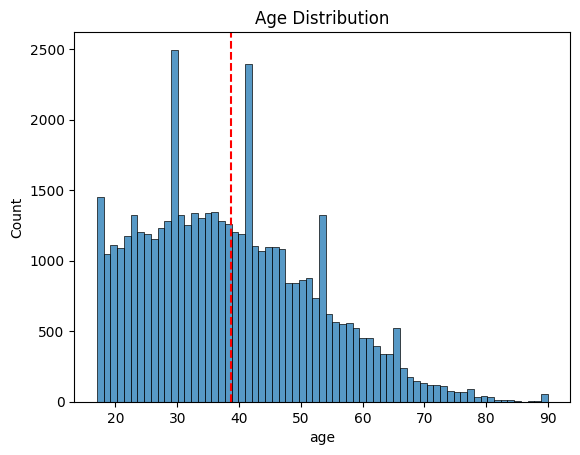

In [96]:
ax = sns.histplot(x=df['age'])
ax.axvline(df['age'].mean(), color='red', linestyle='--')
ax.set_title('Age Distribution')



Age distribution from 18 to 90 years (mean 38 years)

<ipython-input-99-80ba6e051298>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


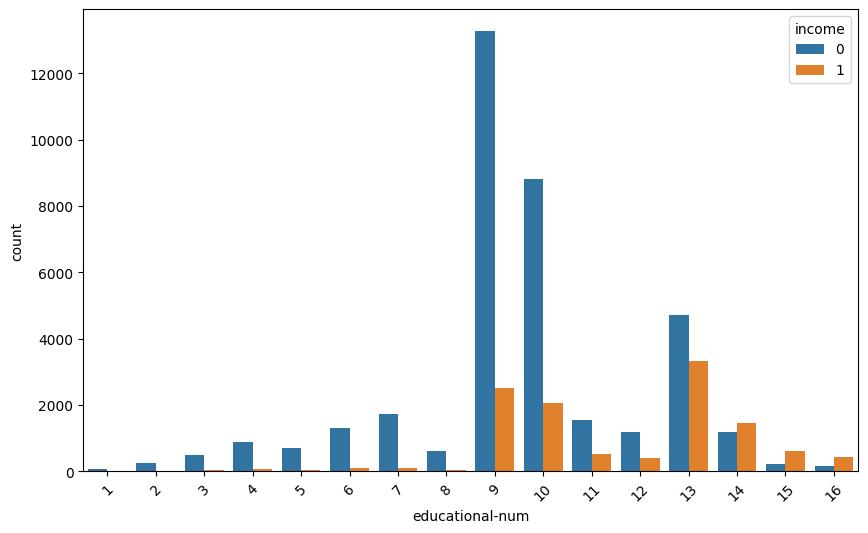

In [99]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='educational-num', hue='income', data=df)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()

when the educational number increase the income also increase.

<Axes: ylabel='count'>

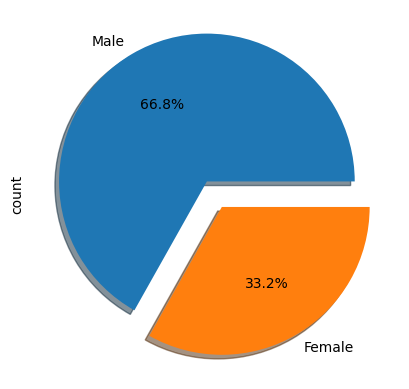

In [100]:
df['gender'].value_counts().plot(kind='pie', autopct="%0.1f%%", explode=[0.1, 0.1], shadow=True)

66.8% is male and 33.2% is female

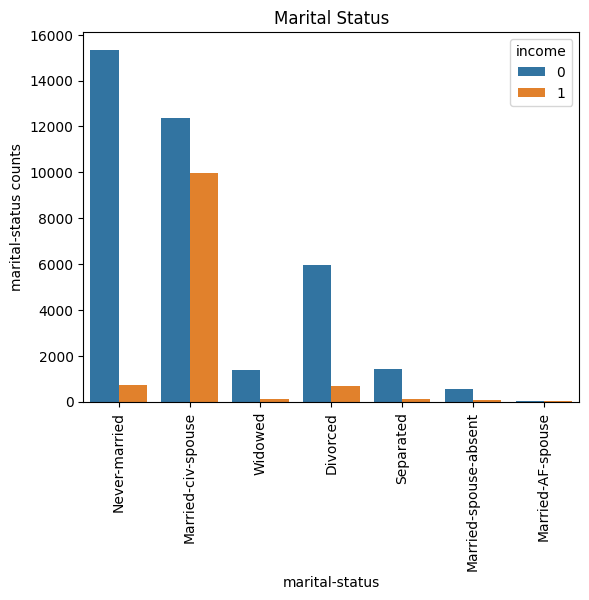

In [101]:
sns.countplot(data =df , x= 'marital-status', hue='income')
plt.title('Marital Status')
plt.xlabel('marital-status')
plt.ylabel('marital-status counts')
plt.xticks(rotation=90)
plt.show()

The majority  of high income are married civ spouse

Text(0.5, 1.0, 'Income Distribution')

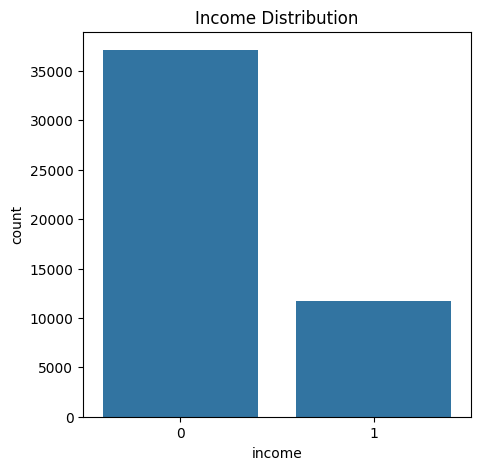

In [102]:
plt.figure(figsize=(5,5))
ax=sns.countplot(x=df['income'])
ax.set_title('Income Distribution')

More than 35000 sample thire income less than or equal 50k

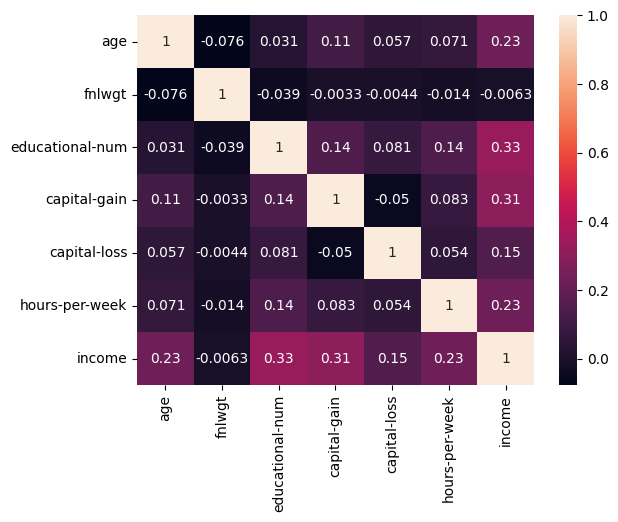

In [104]:
corr= df.corr(numeric_only=True)
ax=sns.heatmap(corr,annot=True)

Moderate relationship between income and capital gain and educational number

## Preprocessing

In [105]:
X= df.drop(columns=['income','fnlwgt'])
y= df['income']

In [106]:
# Train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [107]:
y_train.value_counts(normalize=True) * 100

,proportion
income,
0,76.084937
1,23.915063


- Imbalanced

In [108]:
# Prepare numirecal pipeline
num_cols = X_train.select_dtypes('number').columns
scaler = StandardScaler()
simple_imputer_num = SimpleImputer(strategy='constant', fill_value=-1)
num_pipe = make_pipeline(simple_imputer_num, scaler)
num_tuple = ('num', num_pipe, num_cols)

In [109]:
ohe_cols = X_train.select_dtypes('object').columns
impute_common = SimpleImputer(strategy='constant',fill_value='Missing')
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_pipe = make_pipeline( impute_common,ohe_encoder)


In [110]:
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

In [111]:
X_train.dtypes

,0
age,int64
workclass,object
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object
capital-gain,float64


In [112]:
preprocessor= ColumnTransformer([num_tuple,ohe_tuple],verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value=-1,
                                                                strategy='constant')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                  verbose_feature_names_out=False)

## Modeling

In this task the Logistic Regression model will be used

In [113]:
smote = SMOTE(random_state=42)

#### Default Model

In [114]:
log_reg = LogisticRegression(random_state=42)
log_pipe = make_sampler_pipeline(preprocessor,smote, log_reg)
model=log_pipe.fit(X_train, y_train)
model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value=-1,
                                                                                 strategy='constant')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImp...
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('smote', SMOTE(random_state=42)),
                ('logisticregression', LogisticRegression(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.80      0.86     27841
           1       0.57      0.84      0.68      8751

    accuracy                           0.81     36592
   macro avg       0.76      0.82      0.77     36592
weighted avg       0.85      0.81      0.82     36592



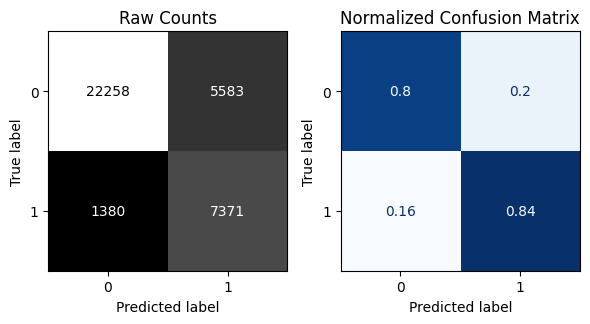


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      9268
           1       0.57      0.83      0.68      2930

    accuracy                           0.81     12198
   macro avg       0.75      0.82      0.77     12198
weighted avg       0.85      0.81      0.82     12198



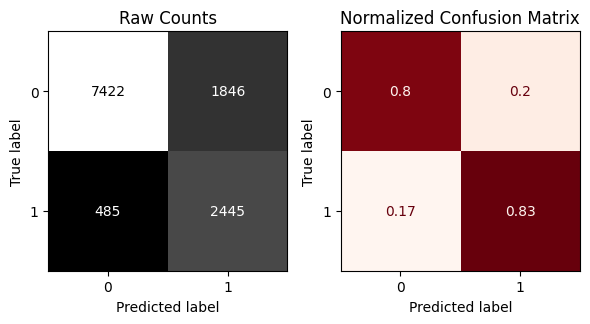

In [115]:
evaluate_classification(log_pipe, X_train, y_train, X_test, y_test)

Clear overfitting, accuracy 81%

### Permutation Importance

In [116]:
from sklearn.inspection import permutation_importance
r = permutation_importance(log_pipe, X_test, y_test,n_repeats =10, random_state = 42)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [117]:
permutation_importances = pd.Series(r['importances_mean'],index=X_test.columns,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
marital-status,0.086498
educational-num,0.021225
capital-gain,0.018856
occupation,0.012338
relationship,0.003378
workclass,0.001886
capital-loss,0.001418
hours-per-week,0.000844
native-country,0.000172
education,0.000008


In [118]:
def plot_importance(importances, top_n=None,  figsize=(8,6)):
    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Importance',
            ylabel='Feature Names',
            title=title)
    ## return ax in case want to continue to update/modify figure
    return ax

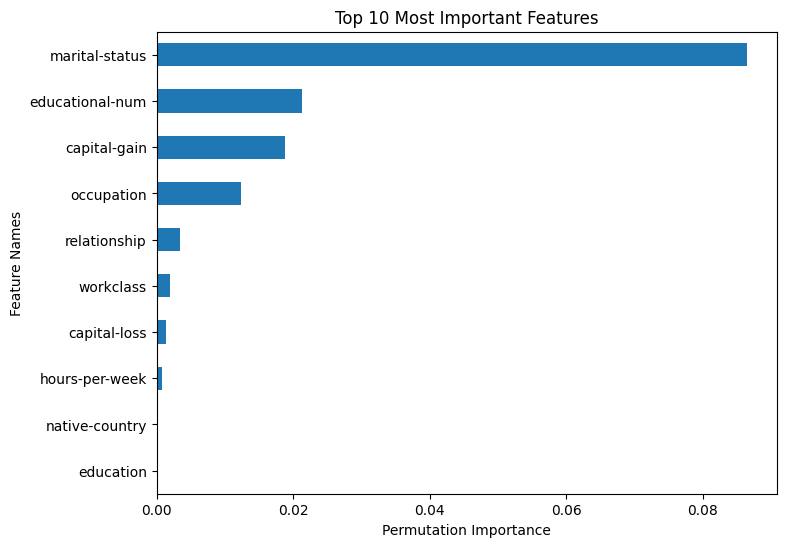

In [119]:
ax = plot_importance(permutation_importances,top_n=10)
ax.set(xlabel='Permutation Importance');


As shown previously in data exploratory section, the marital status and educational number have direct impact on our target (income)